# 13 · Ensambles y Gradient Boosting Avanzado — Sprint 4
**Proyecto:** Detección de Sitios Web Fraudulentos (Phishing)  
**Sprint 4 — PB-14:** Técnicas avanzadas — Voting, Stacking, XGBoost, LightGBM

---

## Objetivo

Combinar los modelos tuneados del Sprint 4 en estructuras de ensamble para obtener predicciones más robustas:

| Técnica | Descripción | Uso principal |
|---------|-------------|---------------|
| **Voting (Soft)** | Promedio de probabilidades de modelos diversos | Modelos base buenos y complementarios |
| **Bagging** | Entrenamiento en subsets aleatorios | Reducir varianza (overfitting) |
| **XGBoost** | Gradient boosting con regularización avanzada | Mayor precisión en datos tabulares |
| **LightGBM** | Boosting basado en histogramas (rápido) | Datasets grandes, alto rendimiento |
| **Stacking** | Meta-learner sobre predicciones base | Combinar modelos de tipos muy distintos |

> **Principio de Occam:** si un modelo tuneado ya cumple los criterios de éxito, se prefiere la solución más simple. Los ensambles se justifican solo si mejoran significativamente.

## 1. Imports y configuración

In [25]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import (
    VotingClassifier,
    StackingClassifier,
    BaggingClassifier,
)
from sklearn.linear_model import LogisticRegression

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print('⚠️  XGBoost no instalado. Instalar con: pip install xgboost')
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    print('⚠️  LightGBM no instalado. Instalar con: pip install lightgbm')
    LGBM_AVAILABLE = False

from src.models import build_full_pipeline, load_model
from src.tuning import log_experiment

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('✓ Librerías cargadas.')
print(f'  XGBoost disponible: {XGBOOST_AVAILABLE}')
print(f'  LightGBM disponible: {LGBM_AVAILABLE}')

✓ Librerías cargadas.
  XGBoost disponible: True
  LightGBM disponible: True


## 2. Cargar datos y modelos tuneados del Sprint 4

In [26]:
TARGET_COL = 'Result'

# Datos de entrenamiento
train_df = pd.read_csv('../data/processed/train.csv')
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

# Preprocessor
preprocessor = joblib.load('../models/preprocessor.pkl')

# Modelos tuneados del Sprint 4 (PB-13)
tuned_rf = joblib.load('../models/tuned_random_forest.pkl')
tuned_gb = joblib.load('../models/tuned_gradient_boosting.pkl')
tuned_lr = joblib.load('../models/tuned_logistic_regression.pkl')

print(f'X_train: {X_train.shape} | Distribución: {dict(y_train.value_counts().sort_index())}')
print('✅ Modelos tuneados cargados correctamente.')

X_train: (4830, 37) | Distribución: {-1: np.int64(2415), 1: np.int64(2415)}
✅ Modelos tuneados cargados correctamente.


In [28]:
# CV estratificado global
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'f1':        'f1',
    'roc_auc':   'roc_auc',
    'recall':    'recall',
    'precision': 'precision',
}


def eval_ensemble(model, X, y, cv, name):
    scoring = ['f1', 'precision', 'recall']   # sin roc_auc
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    metrics = {
        'Modelo':    name,
        'F1':        round(res['test_f1'].mean(), 4),
        'F1_std':    round(res['test_f1'].std(), 4),
        'Precision': round(res['test_precision'].mean(), 4),
        'Recall':    round(res['test_recall'].mean(), 4),
    }
    print(f"  {name}: F1={metrics['F1']:.4f} ± {metrics['F1_std']:.4f}")
    return metrics
print('Función eval_ensemble lista.')

Función eval_ensemble lista.


## 3. Voting Classifier (Soft Voting)

El **Soft Voting** promedia las probabilidades predichas por cada modelo. Funciona mejor cuando los modelos base son diversos y calibrados.

Los estimadores dentro del `VotingClassifier` deben ser los **clasificadores entrenados** (ya incluyen el preprocesador en su pipeline interno).

In [30]:
# Soft Voting: RF + GB + LR (modelos ya incluyen preproc)
voting_soft = VotingClassifier(
    estimators=[
        ('rf', tuned_rf),
        ('gb', tuned_gb),
        ('lr', tuned_lr),
    ],
    voting='soft',
    n_jobs=-1,
)

print('🗳️  Evaluando Soft Voting (RF + GB + LR)...')
metrics_voting = eval_ensemble(voting_soft, X_train, y_train, CV, 'Voting Soft (RF+GB+LR)')

# Hard Voting para comparación
voting_hard = VotingClassifier(
    estimators=[
        ('rf', tuned_rf),
        ('gb', tuned_gb),
        ('lr', tuned_lr),
    ],
    voting='hard',
    n_jobs=-1,
)

print('\n🗳️  Evaluando Hard Voting (RF + GB + LR)...')
metrics_voting_hard = eval_ensemble(voting_hard, X_train, y_train, CV, 'Voting Hard (RF+GB+LR)')

🗳️  Evaluando Soft Voting (RF + GB + LR)...
  Voting Soft (RF+GB+LR): F1=0.9477 ± 0.0051

🗳️  Evaluando Hard Voting (RF + GB + LR)...
  Voting Hard (RF+GB+LR): F1=0.9477 ± 0.0034


## 4. Bagging Classifier

Se aplica **BaggingClassifier** sobre el modelo que mostró mayor overfitting en el Sprint 3. El bagging reduce la varianza entrenando múltiples instancias del mismo estimador en subsets aleatorios de datos.

In [32]:
# Bagging sobre el modelo tuneado (Decision Tree original como base para máxima diversidad)
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

# Construir pipeline de bagging: preproc + Bagging(DT)
pipe_bagging = build_full_pipeline(
    preprocessor,
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10),
        n_estimators=150,
        max_samples=0.8,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)

print('🎲  Evaluando BaggingClassifier (DT base, n=150)...')
metrics_bagging = eval_ensemble(pipe_bagging, X_train, y_train, CV, 'Bagging (DT base)')

🎲  Evaluando BaggingClassifier (DT base, n=150)...
  Bagging (DT base): F1=0.9452 ± 0.0076


## 5. XGBoost

**XGBoost** extiende el gradient boosting con regularización L1/L2, manejo nativo de valores faltantes y soporte para early stopping. Suele ser uno de los algoritmos más competitivos en datos tabulares.

In [34]:
if XGBOOST_AVAILABLE:
    pipe_xgb = build_full_pipeline(
        preprocessor,
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,        # L1 regularization
            reg_lambda=1.0,       # L2 regularization
            eval_metric='logloss',
            use_label_encoder=False,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    )
    # Mapear etiquetas: -1 -> 0, 1 -> 1
    y_train = y_train.map({-1: 0, 1: 1})
    print('⚡ Evaluando XGBoost...')
    metrics_xgb = eval_ensemble(pipe_xgb, X_train, y_train, CV, 'XGBoost')

    # Persistir
    joblib.dump(pipe_xgb.fit(X_train, y_train), '../models/tuned_xgboost.pkl')
    print('   Modelo XGBoost persistido en models/tuned_xgboost.pkl')
else:
    print('⚠️  XGBoost no disponible. Se omite esta sección.')
    metrics_xgb = None

⚡ Evaluando XGBoost...
  XGBoost: F1=0.9506 ± 0.0062
   Modelo XGBoost persistido en models/tuned_xgboost.pkl


## 6. LightGBM

**LightGBM** usa un algoritmo basado en histogramas que lo hace considerablemente más rápido que XGBoost en datasets grandes. Usa crecimiento leaf-wise en lugar de level-wise.

In [36]:
if LGBM_AVAILABLE:
    pipe_lgbm = build_full_pipeline(
        preprocessor,
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    )

    print('🌿 Evaluando LightGBM...')
    metrics_lgbm = eval_ensemble(pipe_lgbm, X_train, y_train, CV, 'LightGBM')

    # Persistir
    joblib.dump(pipe_lgbm.fit(X_train, y_train), '../models/tuned_lgbm.pkl')
    print('   Modelo LightGBM persistido en models/tuned_lgbm.pkl')
else:
    print('⚠️  LightGBM no disponible. Se omite esta sección.')
    metrics_lgbm = None

🌿 Evaluando LightGBM...
  LightGBM: F1=0.9506 ± 0.0054
   Modelo LightGBM persistido en models/tuned_lgbm.pkl


## 7. Stacking Classifier

El **StackingClassifier** usa las predicciones de los modelos base como features para un meta-learner. Es más flexible pero requiere más cuidado para evitar overfitting.

**Arquitectura:** RF + GB como estimadores base → Logistic Regression como meta-learner.

In [37]:
# Stacking: RF + GB → Logistic Regression meta-learner
stacking = StackingClassifier(
    estimators=[
        ('rf', tuned_rf),
        ('gb', tuned_gb),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=CV,
    passthrough=False,   # No pasar features originales al meta-learner
    n_jobs=-1,
)

print('🥞 Evaluando Stacking (RF+GB → LR meta-learner)...')
metrics_stacking = eval_ensemble(stacking, X_train, y_train, CV, 'Stacking (RF+GB → LR)')

# Persistir stacking
joblib.dump(stacking.fit(X_train, y_train), '../models/tuned_stacking.pkl')
print('   Modelo Stacking persistido en models/tuned_stacking.pkl')

🥞 Evaluando Stacking (RF+GB → LR meta-learner)...
  Stacking (RF+GB → LR): F1=0.9475 ± 0.0052
   Modelo Stacking persistido en models/tuned_stacking.pkl


## 8. Tabla comparativa — Todos los ensambles

In [38]:
# Recopilar todos los resultados
all_results = [metrics_voting, metrics_voting_hard, metrics_bagging, metrics_stacking]

if metrics_xgb:
    all_results.append(metrics_xgb)
if metrics_lgbm:
    all_results.append(metrics_lgbm)

# Añadir referencia del mejor baseline tuneado
from sklearn.model_selection import cross_validate as cvx
res_rf_ref = cvx(tuned_rf, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=-1)
all_results.insert(0, {
    'Modelo':    '▶ RF Tuned (referencia)',
    'F1':        round(res_rf_ref['test_f1'].mean(), 4),
    'F1_std':    round(res_rf_ref['test_f1'].std(), 4),
    'AUC-ROC':   round(res_rf_ref['test_roc_auc'].mean(), 4),
    'Recall':    round(res_rf_ref['test_recall'].mean(), 4),
    'Precision': round(res_rf_ref['test_precision'].mean(), 4),
})

df_ensembles = pd.DataFrame(all_results).sort_values('F1', ascending=False).reset_index(drop=True)
df_ensembles.index += 1

# Guardar para referencia
df_ensembles.to_csv('../models/ensemble_comparison.csv', index=False)

print('\n📊 TABLA COMPARATIVA — ENSAMBLES vs. BASELINE TUNEADO')
print(df_ensembles.to_string())


📊 TABLA COMPARATIVA — ENSAMBLES vs. BASELINE TUNEADO
                    Modelo      F1  F1_std  AUC-ROC  Recall  Precision
1                 LightGBM  0.9506  0.0054      NaN  0.9553     0.9460
2                  XGBoost  0.9506  0.0062      NaN  0.9565     0.9449
3   Voting Soft (RF+GB+LR)  0.9477  0.0051      NaN  0.9557     0.9399
4   Voting Hard (RF+GB+LR)  0.9477  0.0034      NaN  0.9557     0.9399
5    Stacking (RF+GB → LR)  0.9475  0.0052      NaN  0.9524     0.9428
6        Bagging (DT base)  0.9452  0.0076      NaN  0.9536     0.9370
7  ▶ RF Tuned (referencia)  0.9442  0.0063   0.9879  0.9532     0.9355


## 9. Visualización comparativa

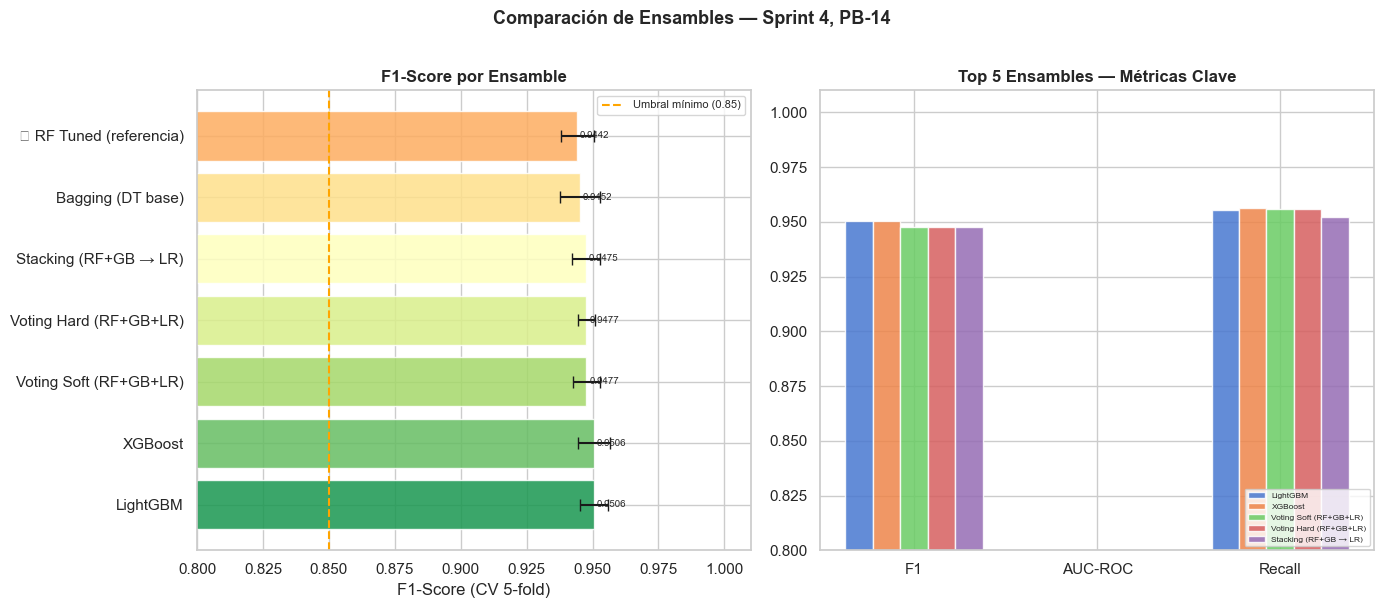

✅ Gráfico guardado.


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: F1 con barras de error
ax0 = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_ensembles)))
bars = ax0.barh(df_ensembles['Modelo'], df_ensembles['F1'],
                xerr=df_ensembles.get('F1_std', 0),
                color=colors[::-1], alpha=0.85, capsize=4)
ax0.axvline(0.85, color='orange', linestyle='--', linewidth=1.5, label='Umbral mínimo (0.85)')
ax0.set_xlabel('F1-Score (CV 5-fold)')
ax0.set_title('F1-Score por Ensamble', fontweight='bold')
ax0.legend(fontsize=8)
ax0.set_xlim(0.8, 1.01)
for bar, val in zip(bars, df_ensembles['F1']):
    ax0.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=7)

# Gráfico 2: Radar / comparación F1 + AUC + Recall
ax1 = axes[1]
top5 = df_ensembles.head(5)
x = np.arange(3)
width = 0.15
for i, (_, row) in enumerate(top5.iterrows()):
    ax1.bar(x + i * width,
            [row['F1'], row['AUC-ROC'], row['Recall']],
            width, label=row['Modelo'][:30], alpha=0.85)
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(['F1', 'AUC-ROC', 'Recall'])
ax1.set_ylim(0.80, 1.01)
ax1.set_title('Top 5 Ensambles — Métricas Clave', fontweight='bold')
ax1.legend(fontsize=6, loc='lower right')

plt.suptitle('Comparación de Ensambles — Sprint 4, PB-14', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado.')

## 10. Selección del mejor modelo para validación final

Se selecciona el modelo con mejor F1 en CV para pasarlo al notebook de validación final (`14_final_validation.ipynb`).

In [40]:
# El mejor modelo según F1 en CV
best_row = df_ensembles.iloc[0]
print(f'🏆 MEJOR MODELO PARA VALIDACIÓN FINAL:')
print(f'   Modelo:    {best_row["Modelo"]}')
print(f'   F1 (CV):   {best_row["F1"]:.4f} ± {best_row.get("F1_std", "N/A")}')
print(f'   AUC-ROC:   {best_row["AUC-ROC"]:.4f}')
print(f'   Recall:    {best_row["Recall"]:.4f}')
print(f'   Precision: {best_row["Precision"]:.4f}')

# Determinar el objeto del mejor modelo
# Usar mapa nombre → objeto para seleccionar el correcto
model_map = {
    '▶ RF Tuned (referencia)':       tuned_rf,
    'Voting Soft (RF+GB+LR)':        voting_soft,
    'Voting Hard (RF+GB+LR)':        voting_hard,
    'Bagging (DT base)':             pipe_bagging,
    'Stacking (RF+GB → LR)':         stacking,
}
if XGBOOST_AVAILABLE:
    model_map['XGBoost'] = pipe_xgb
if LGBM_AVAILABLE:
    model_map['LightGBM'] = pipe_lgbm

best_model_name = best_row['Modelo']
best_model = model_map.get(best_model_name, tuned_rf)

# Entrenar en todo el train set y persistir como final_model
best_model.fit(X_train, y_train)
joblib.dump(best_model, '../models/final_model.pkl')

print(f'\n✅ Modelo final persistido en models/final_model.pkl')
print('   → Listo para validación en 14_final_validation.ipynb')
print('\n⚠️  RECORDATORIO: El test set NO se ha usado en ningún momento.')

🏆 MEJOR MODELO PARA VALIDACIÓN FINAL:
   Modelo:    LightGBM
   F1 (CV):   0.9506 ± 0.0054
   AUC-ROC:   nan
   Recall:    0.9553
   Precision: 0.9460

✅ Modelo final persistido en models/final_model.pkl
   → Listo para validación en 14_final_validation.ipynb

⚠️  RECORDATORIO: El test set NO se ha usado en ningún momento.


## 11. Análisis de Feature Importance (Post-tuning)

Se analiza la importancia de features del modelo final para proveer interpretabilidad al equipo de negocio (Sprint 5).

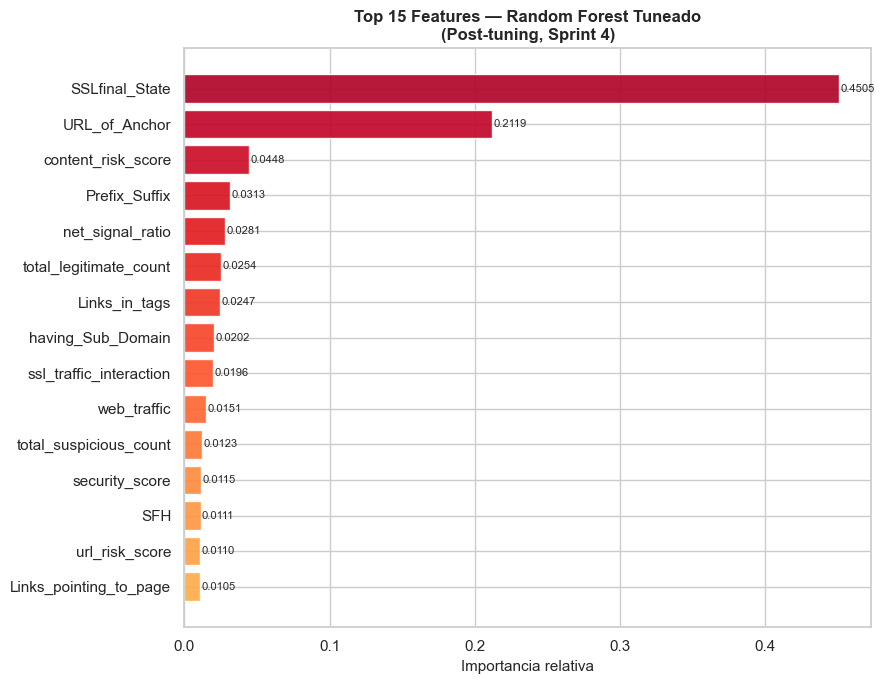

✅ Feature importance guardada.


In [41]:
# Intentar extraer feature importance del mejor modelo
def get_feature_importance(pipeline, feature_names):
    """Extrae feature importance si el modelo la soporta."""
    clf = pipeline.named_steps.get('clf', None)
    if clf is None and hasattr(pipeline, 'estimators_'):
        # Es un ensemble de pipelines
        for name, est in pipeline.named_estimators_.items() if hasattr(pipeline, 'named_estimators_') else []:
            sub_clf = est.named_steps.get('clf', None)
            if sub_clf and hasattr(sub_clf, 'feature_importances_'):
                return sub_clf.feature_importances_, name
        return None, None
    if clf and hasattr(clf, 'feature_importances_'):
        return clf.feature_importances_, 'Model'
    return None, None

# Usar RF tuneado para feature importance (siempre tiene esta propiedad)
tuned_rf.fit(X_train, y_train)
rf_clf = tuned_rf.named_steps['clf']
importances = rf_clf.feature_importances_

fi = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 15)[::-1])
ax.barh(fi['feature'][:15], fi['importance'][:15], color=colors_fi, alpha=0.9)
ax.set_xlabel('Importancia relativa', fontsize=11)
ax.set_title('Top 15 Features — Random Forest Tuneado\n(Post-tuning, Sprint 4)', fontweight='bold')
ax.invert_yaxis()
for i, (feat, imp) in enumerate(zip(fi['feature'][:15], fi['importance'][:15])):
    ax.text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_sprint4.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance guardada.')